In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import shap

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix, classification_report , roc_curve
)

In [5]:
train_df = pd.read_csv("/Users/kongphopkaochot/Desktop/Senior_Project/Practical Datascience/week15/TRAIN_DATASET.csv")
test_df = pd.read_csv("/Users/kongphopkaochot/Desktop/Senior_Project/Practical Datascience/week15/TEST_DATASET.csv")


In [6]:
X_train = train_df.drop(columns=["appendicitis"])
y_train = train_df["appendicitis"]

In [7]:
X_train.head(5)

,Progression,Migration,Aggravation,TEMP,Rebound,WBC,Neut
0,1,1,1,0,1,1,0
1,1,0,1,1,0,1,1
2,1,0,1,0,0,1,1
3,1,1,1,0,1,1,1
4,1,0,1,0,0,1,0


In [8]:
X_test = test_df.drop(columns=["appendicitis"])
y_test = test_df["appendicitis"]

In [9]:
from sklearn.model_selection import KFold
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score

kf = KFold(n_splits=5, shuffle=True, random_state=42)

acc_scores = []
f1_scores = []

for train_idx, val_idx in kf.split(X_train):

    X_tr, X_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
    y_tr, y_val = y_train.iloc[train_idx], y_train.iloc[val_idx]

    model = LogisticRegression(max_iter=1000)
    model.fit(X_tr, y_tr)

    y_pred = model.predict(X_val)

    acc_scores.append(accuracy_score(y_val, y_pred))
    f1_scores.append(f1_score(y_val, y_pred))

print("K-Fold Accuracy:", sum(acc_scores)/len(acc_scores))
print("K-Fold F1:", sum(f1_scores)/len(f1_scores))

K-Fold Accuracy: 0.758
K-Fold F1: 0.8374241825938423


In [10]:
final_model = LogisticRegression(max_iter=1000)
final_model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [11]:
from sklearn.metrics import classification_report, roc_auc_score

y_pred_test = final_model.predict(X_test)
y_prob_test = final_model.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred_test))

auc = roc_auc_score(y_test, y_prob_test)
print("AUC:", auc)

              precision    recall  f1-score   support

           0       0.64      0.43      0.51       110
           1       0.79      0.90      0.84       266

    accuracy                           0.76       376
   macro avg       0.72      0.66      0.68       376
weighted avg       0.75      0.76      0.75       376

AUC: 0.7554682159945318


In [12]:
intercept = final_model.intercept_[0]
coefficients = final_model.coef_[0]
features = X_train.columns

print("=== Logistic Regression Result ===")
print(f"Intercept: {intercept:.4f}")
print("-" * 45)

for name, coef in zip(features, coefficients):
    print(f"Weight of {name:15}: {coef: .4f}")

print("-" * 45)

equation = f"Logit (z) = {intercept:.4f}"

for name, coef in zip(features, coefficients):
    sign = "+" if coef >= 0 else "-"
    equation += f" {sign} ({abs(coef):.4f} * {name})"

print(equation)

=== Logistic Regression Result ===
Intercept: -1.1638
---------------------------------------------
Weight of Progression    :  0.6474
Weight of Migration      : -0.0310
Weight of Aggravation    : -0.0868
Weight of TEMP           : -0.7714
Weight of Rebound        :  1.1534
Weight of WBC            :  0.9001
Weight of Neut           :  1.1809
---------------------------------------------
Logit (z) = -1.1638 + (0.6474 * Progression) - (0.0310 * Migration) - (0.0868 * Aggravation) - (0.7714 * TEMP) + (1.1534 * Rebound) + (0.9001 * WBC) + (1.1809 * Neut)


In [13]:
for col in X_train.columns:
    print(col, train_df[[col, "appendicitis"]].corr().iloc[0,1])

Progression 0.21395673863496362
Migration 0.0820547361415827
Aggravation -0.047503784322739495
TEMP -0.005650016213261255
Rebound 0.2917212450886293
WBC 0.30821891416093444
Neut 0.3058314547201093


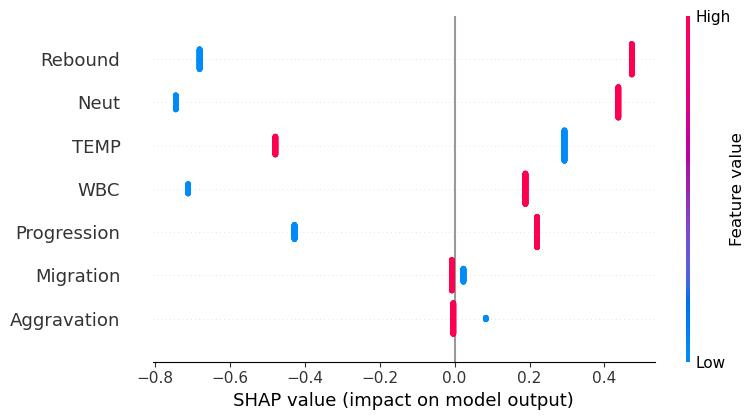

In [14]:
import shap

explainer = shap.Explainer(final_model, X_train)
shap_values = explainer(X_test)

shap.summary_plot(shap_values, X_test)

In [15]:
def doctor_model_proba(df):

    logit = (
        -3.37
        + 0.80 * df["Migration"]
        + 1.04 * df["Progression"]
        + 0.78 * df["Aggravation"]
        + 1.64 * df["TEMP"]
        + 1.53 * df["Rebound"]
        + 0.91 * df["WBC"]
        + 0.69 * df["Neut"]
    )

    prob = 1 / (1 + np.exp(-logit))
    return prob

In [16]:
y_prob_doctor = doctor_model_proba(X_test)

In [17]:
from sklearn.metrics import roc_curve, roc_auc_score

fpr_doc, tpr_doc, _ = roc_curve(y_test, y_prob_doctor)
auc_doc = roc_auc_score(y_test, y_prob_doctor)

In [18]:
y_prob_model = final_model.predict_proba(X_test)[:, 1]
fpr_model, tpr_model, _ = roc_curve(y_test, y_prob_model)
auc_model = roc_auc_score(y_test, y_prob_model)

In [19]:
# ===== doctor model =====
y_prob_doc = doctor_model_proba(X_test)

fpr_doc, tpr_doc, _ = roc_curve(y_test, y_prob_doc)
auc_doc = roc_auc_score(y_test, y_prob_doc)

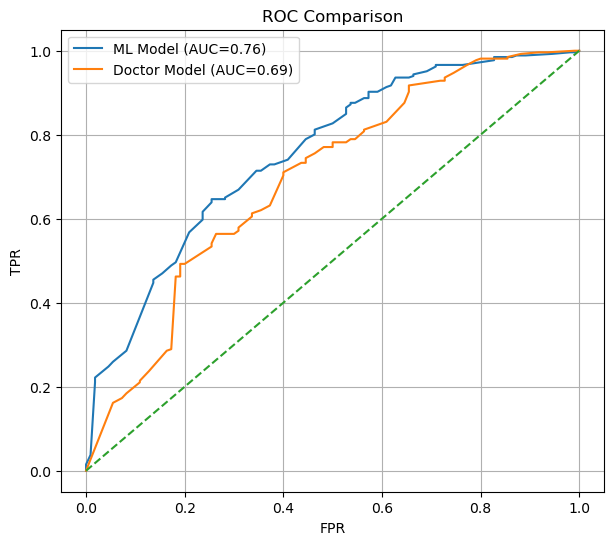

In [20]:
plt.figure(figsize=(7,6))

# model เรา
plt.plot(fpr_model, tpr_model, label=f"ML Model (AUC={auc_model:.2f})")

# model หมอ
plt.plot(fpr_doc, tpr_doc, label=f"Doctor Model (AUC={auc_doc:.2f})")

plt.plot([0,1],[0,1],"--")

plt.xlabel("FPR")
plt.ylabel("TPR")
plt.title("ROC Comparison")
plt.legend()
plt.grid(True)
plt.show()